# 06 — Evaluation & Model Comparison
**Traffic Sign Recognition · GTSRB Dataset**

Goals:
- Load both trained models (Custom CNN + MobileNetV2)
- Preprocess and evaluate on the **held-out test set** (Test.csv)
- Compare validation accuracy vs test accuracy
- Generate confusion matrices
- Visualise correct and incorrect predictions

**Prerequisite**: Notebooks 04 and 05 must have been run to completion.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from src.config import (DATA_DIR, CUSTOM_CNN_FINAL, MOBILENET_FINAL,
                        CLASS_NAMES, NUM_CLASSES)
from src.data_loader import load_test_csv
from src.preprocessing import load_dataset

2026-02-28 03:04:55.706921: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 03:04:56.814804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 03:05:06.432331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load Data & Models

In [2]:
# Load validation set (kept for comparison)
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))

# Load test set — preprocess once then cache as .npy
X_test_path = os.path.join(DATA_DIR, "X_test.npy")
y_test_path = os.path.join(DATA_DIR, "y_test.npy")

if os.path.exists(X_test_path) and os.path.exists(y_test_path):
    print("Loading cached test set …")
    X_test = np.load(X_test_path)
    y_test = np.load(y_test_path)
else:
    print("Preprocessing test set (runs once, then cached) …")
    test_df = load_test_csv()
    X_test, y_test = load_dataset(test_df, DATA_DIR)
    np.save(X_test_path, X_test)
    np.save(y_test_path, y_test)
    print("Test set cached to disk.")

# Load models
cnn_model    = tf.keras.models.load_model(CUSTOM_CNN_FINAL)
mobile_model = tf.keras.models.load_model(MOBILENET_FINAL)

print(f"\nVal  set : {X_val.shape}")
print(f"Test set : {X_test.shape}")
print(f"Custom CNN   params : {cnn_model.count_params():,}")
print(f"MobileNetV2  params : {mobile_model.count_params():,}")

Preprocessing test set (runs once, then cached) …
  [    0/12630] processed …
  [ 1000/12630] processed …
  [ 2000/12630] processed …
  [ 3000/12630] processed …
  [ 4000/12630] processed …
  [ 5000/12630] processed …
  [ 6000/12630] processed …
  [ 7000/12630] processed …
  [ 8000/12630] processed …
  [ 9000/12630] processed …
  [10000/12630] processed …
  [11000/12630] processed …
  [12000/12630] processed …

  Loaded 12630/12630 images successfully.
Test set cached to disk.


I0000 00:00:1772244420.780257   11788 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9



Val  set : (7842, 64, 64, 3)
Test set : (12630, 64, 64, 3)
Custom CNN   params : 4,629,067
MobileNetV2  params : 2,597,995


## 2. Predictions

In [3]:
print("Running inference on test set …")
cnn_proba    = cnn_model.predict(X_test, verbose=0)
mobile_proba = mobile_model.predict(X_test, verbose=0)

y_pred_cnn    = np.argmax(cnn_proba,    axis=1)
y_pred_mobile = np.argmax(mobile_proba, axis=1)

acc_cnn    = accuracy_score(y_test, y_pred_cnn)
acc_mobile = accuracy_score(y_test, y_pred_mobile)

# Val accuracy for comparison
acc_cnn_val    = accuracy_score(y_val, np.argmax(cnn_model.predict(X_val,    verbose=0), axis=1))
acc_mobile_val = accuracy_score(y_val, np.argmax(mobile_model.predict(X_val, verbose=0), axis=1))

print(f"\n{'Model':<15} {'Val Acc':>10} {'Test Acc':>10}")
print(f"{'─' * 37}")
print(f"{'Custom CNN':<15} {acc_cnn_val*100:>9.2f}% {acc_cnn*100:>9.2f}%")
print(f"{'MobileNetV2':<15} {acc_mobile_val*100:>9.2f}% {acc_mobile*100:>9.2f}%")

Running inference on test set …


2026-02-28 03:07:06.589071: I external/local_xla/xla/service/service.cc:163] XLA service 0x746a7000e880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-28 03:07:06.589124: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-02-28 03:07:06.655000: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-28 03:07:06.825736: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-28 03:07:06.889248: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-28 03:07:07.445553: I e


Model              Val Acc   Test Acc
─────────────────────────────────────
Custom CNN          99.90%     98.75%
MobileNetV2         89.10%     80.03%


## 3. Accuracy Comparison Bar Chart

      Model  Val Accuracy  Test Accuracy  Parameters
 Custom CNN      0.998980       0.987490     4629067
MobileNetV2      0.890972       0.800317     2597995


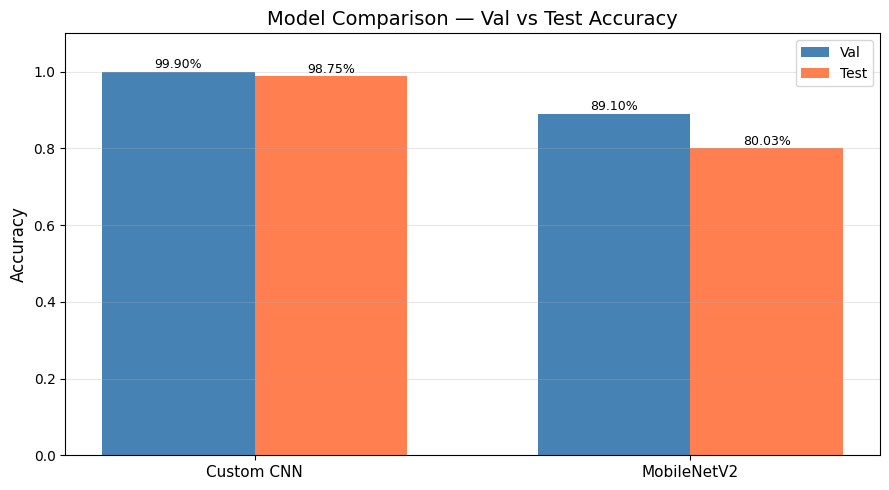

In [4]:
models_df = pd.DataFrame({
    'Model':         ['Custom CNN', 'MobileNetV2'],
    'Val Accuracy':  [acc_cnn_val,  acc_mobile_val],
    'Test Accuracy': [acc_cnn,      acc_mobile],
    'Parameters':    [cnn_model.count_params(), mobile_model.count_params()],
})
print(models_df.to_string(index=False))

x     = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, models_df['Val Accuracy'],  width, label='Val',  color='steelblue')
bars2 = ax.bar(x + width/2, models_df['Test Accuracy'], width, label='Test', color='coral')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h*100:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_df['Model'], fontsize=11)
ax.set_ylim([0, 1.1])
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison — Val vs Test Accuracy', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Confusion Matrix — Custom CNN

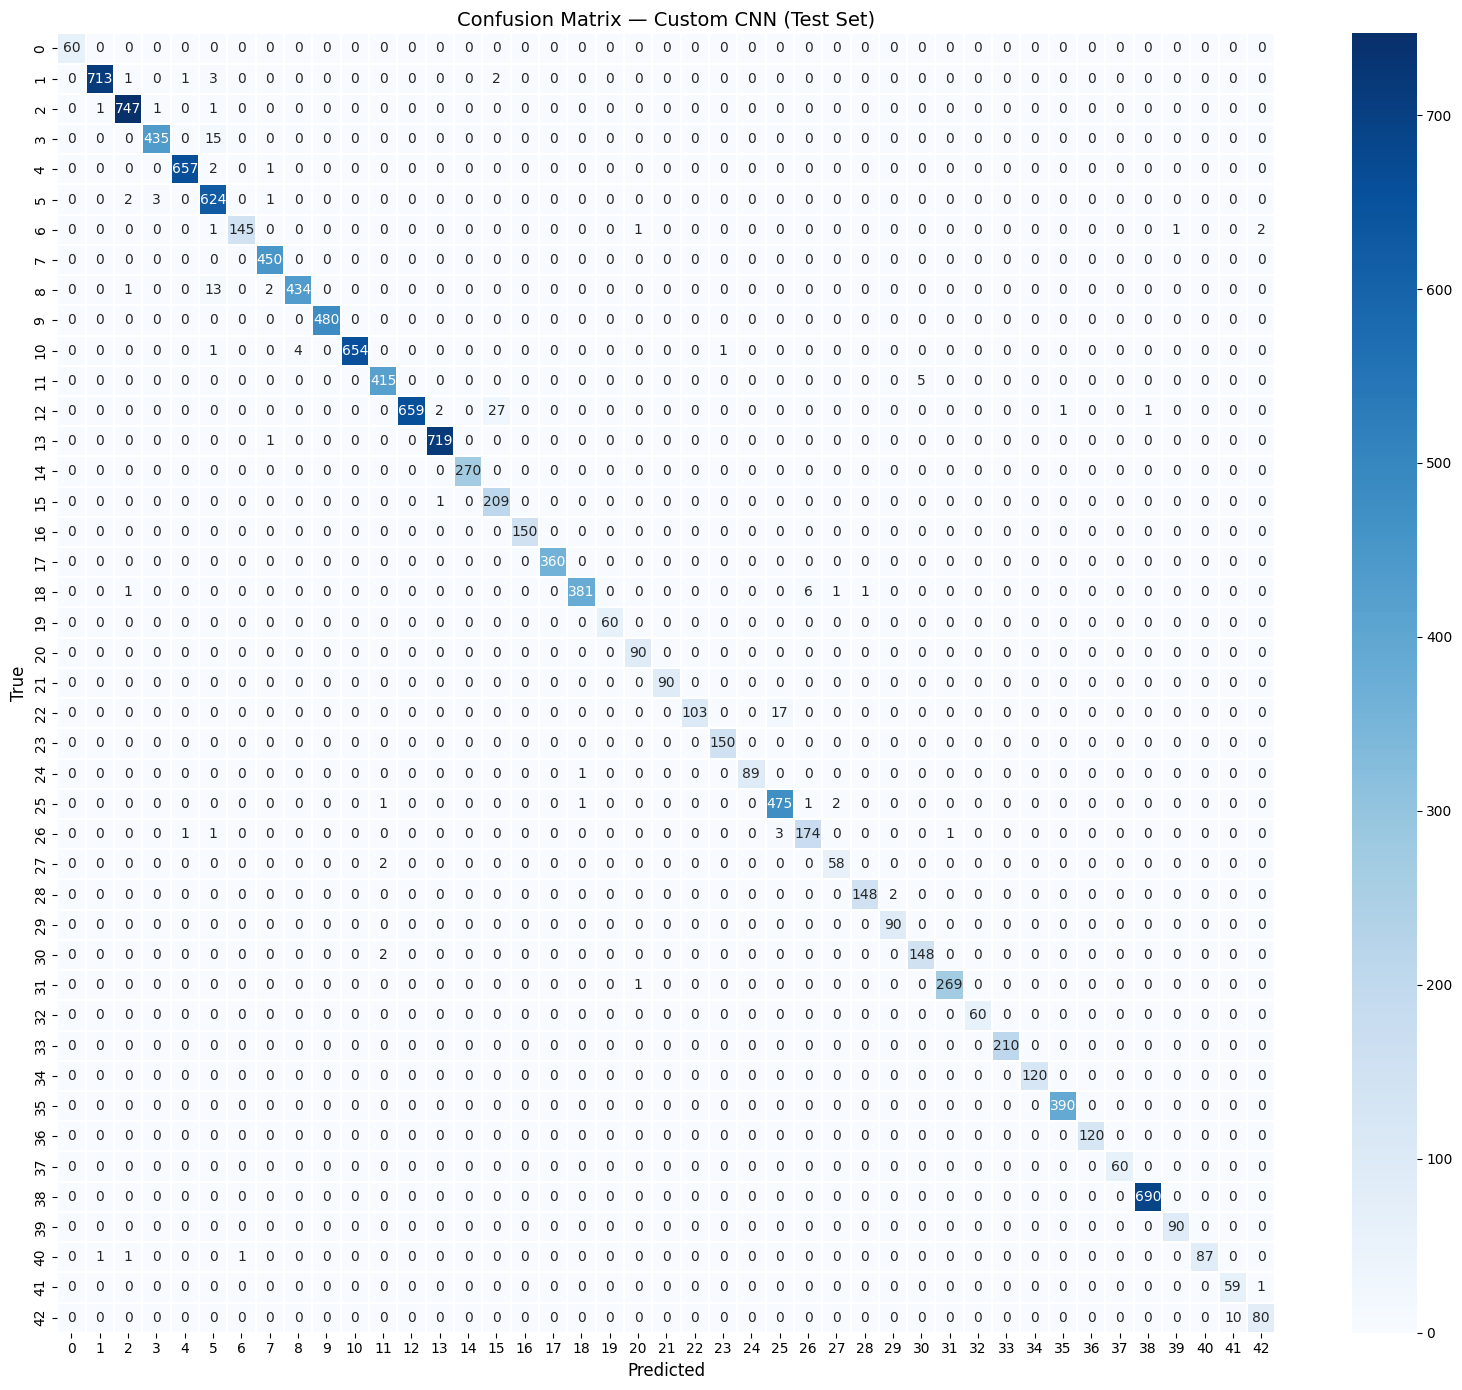

In [5]:
def plot_confusion_matrix(y_true, y_pred, title, figsize=(16, 14)):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES),
                linewidths=0.3, cbar=True)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True',      fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return cm

cm_cnn = plot_confusion_matrix(y_test, y_pred_cnn, 'Confusion Matrix — Custom CNN (Test Set)')

## 5. Confusion Matrix — MobileNetV2

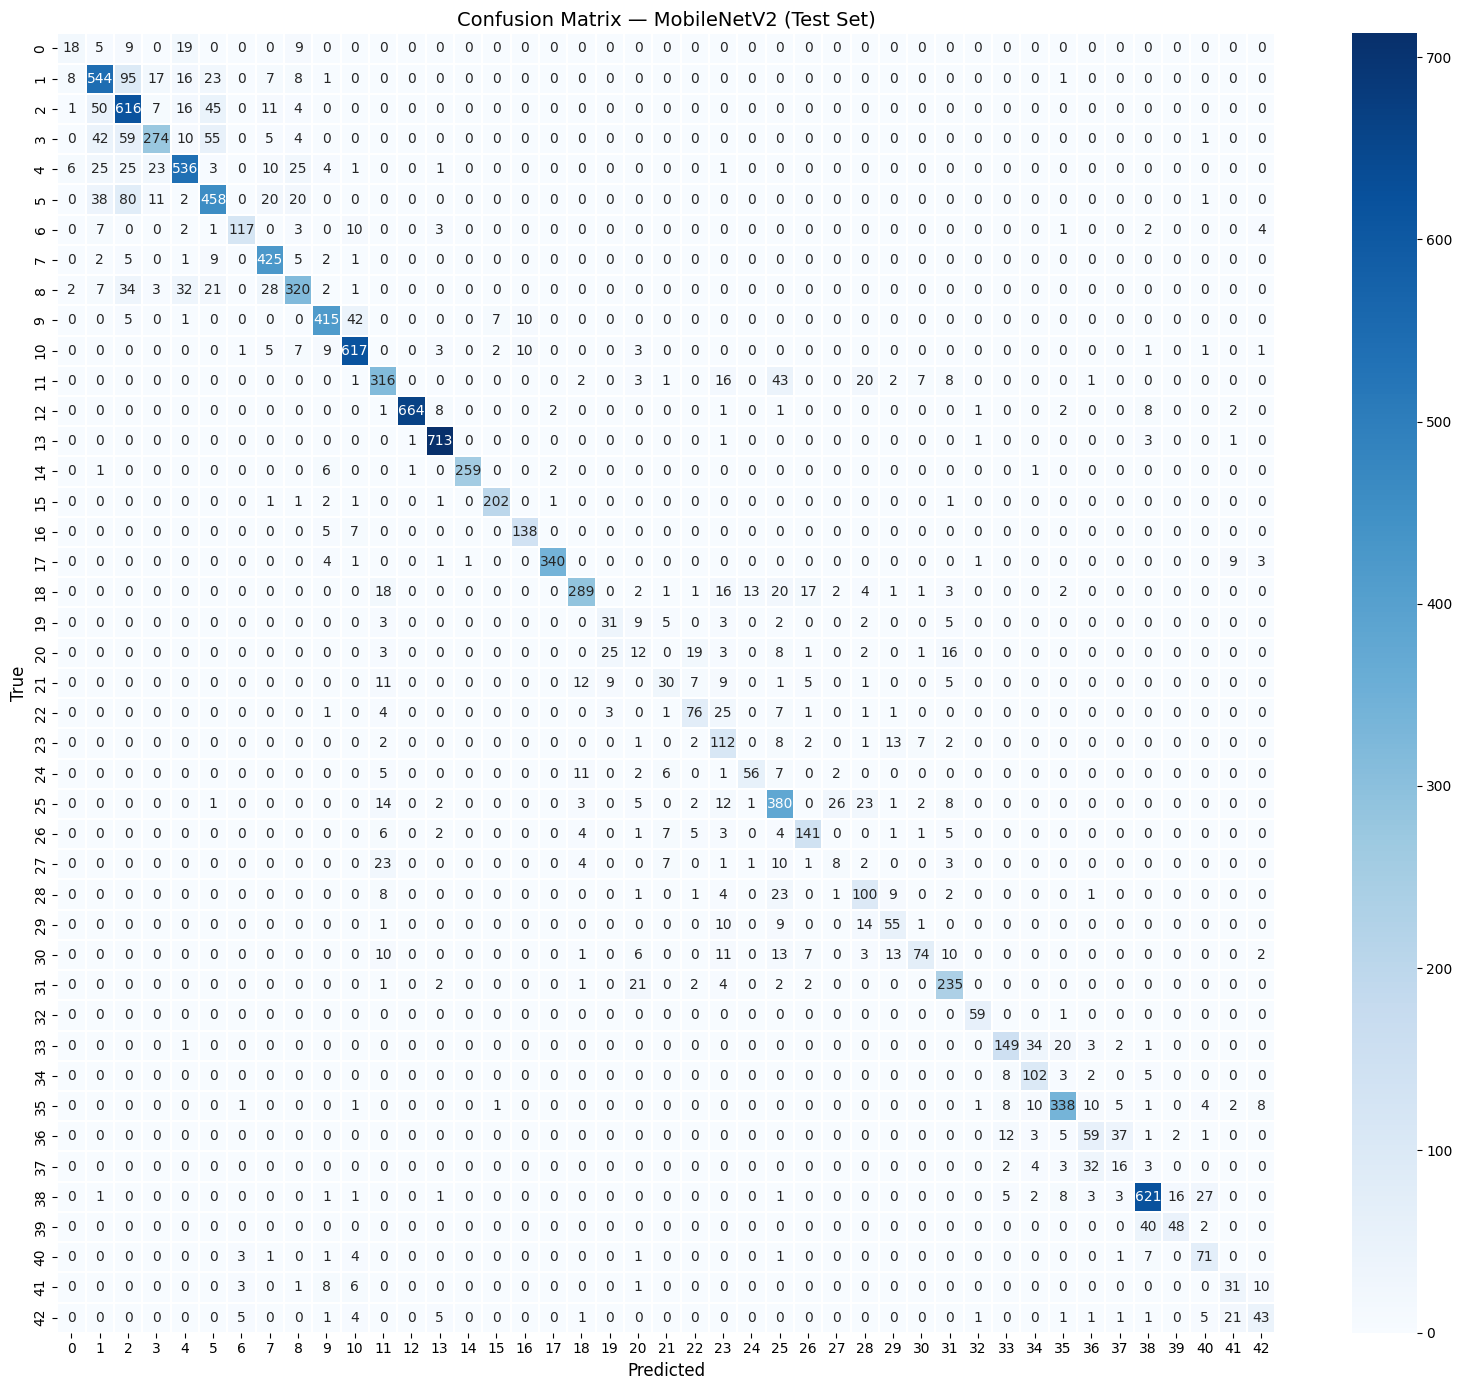

In [6]:
cm_mobile = plot_confusion_matrix(y_test, y_pred_mobile, 'Confusion Matrix — MobileNetV2 (Test Set)')

## 6. Classification Report — Best Model

In [7]:
best_pred = y_pred_cnn if acc_cnn >= acc_mobile else y_pred_mobile
best_name = 'Custom CNN' if acc_cnn >= acc_mobile else 'MobileNetV2'
print(f"Classification Report — {best_name} (Test Set)")
print(classification_report(y_test, best_pred,
                            target_names=[f'{i}: {CLASS_NAMES[i][:20]}'
                                          for i in range(NUM_CLASSES)]))

Classification Report — Custom CNN (Test Set)
                          precision    recall  f1-score   support

 0: Speed limit (20km/h)       1.00      1.00      1.00        60
 1: Speed limit (30km/h)       1.00      0.99      0.99       720
 2: Speed limit (50km/h)       0.99      1.00      0.99       750
 3: Speed limit (60km/h)       0.99      0.97      0.98       450
 4: Speed limit (70km/h)       1.00      1.00      1.00       660
 5: Speed limit (80km/h)       0.94      0.99      0.97       630
 6: End of speed limit (       0.99      0.97      0.98       150
 7: Speed limit (100km/h       0.99      1.00      0.99       450
 8: Speed limit (120km/h       0.99      0.96      0.98       450
           9: No passing       1.00      1.00      1.00       480
  10: No passing (>3.5t)       1.00      0.99      1.00       660
11: Right-of-way at inte       0.99      0.99      0.99       420
       12: Priority road       1.00      0.96      0.98       690
               13: Yield     

## 7. Sample Predictions (correct = green, wrong = red)

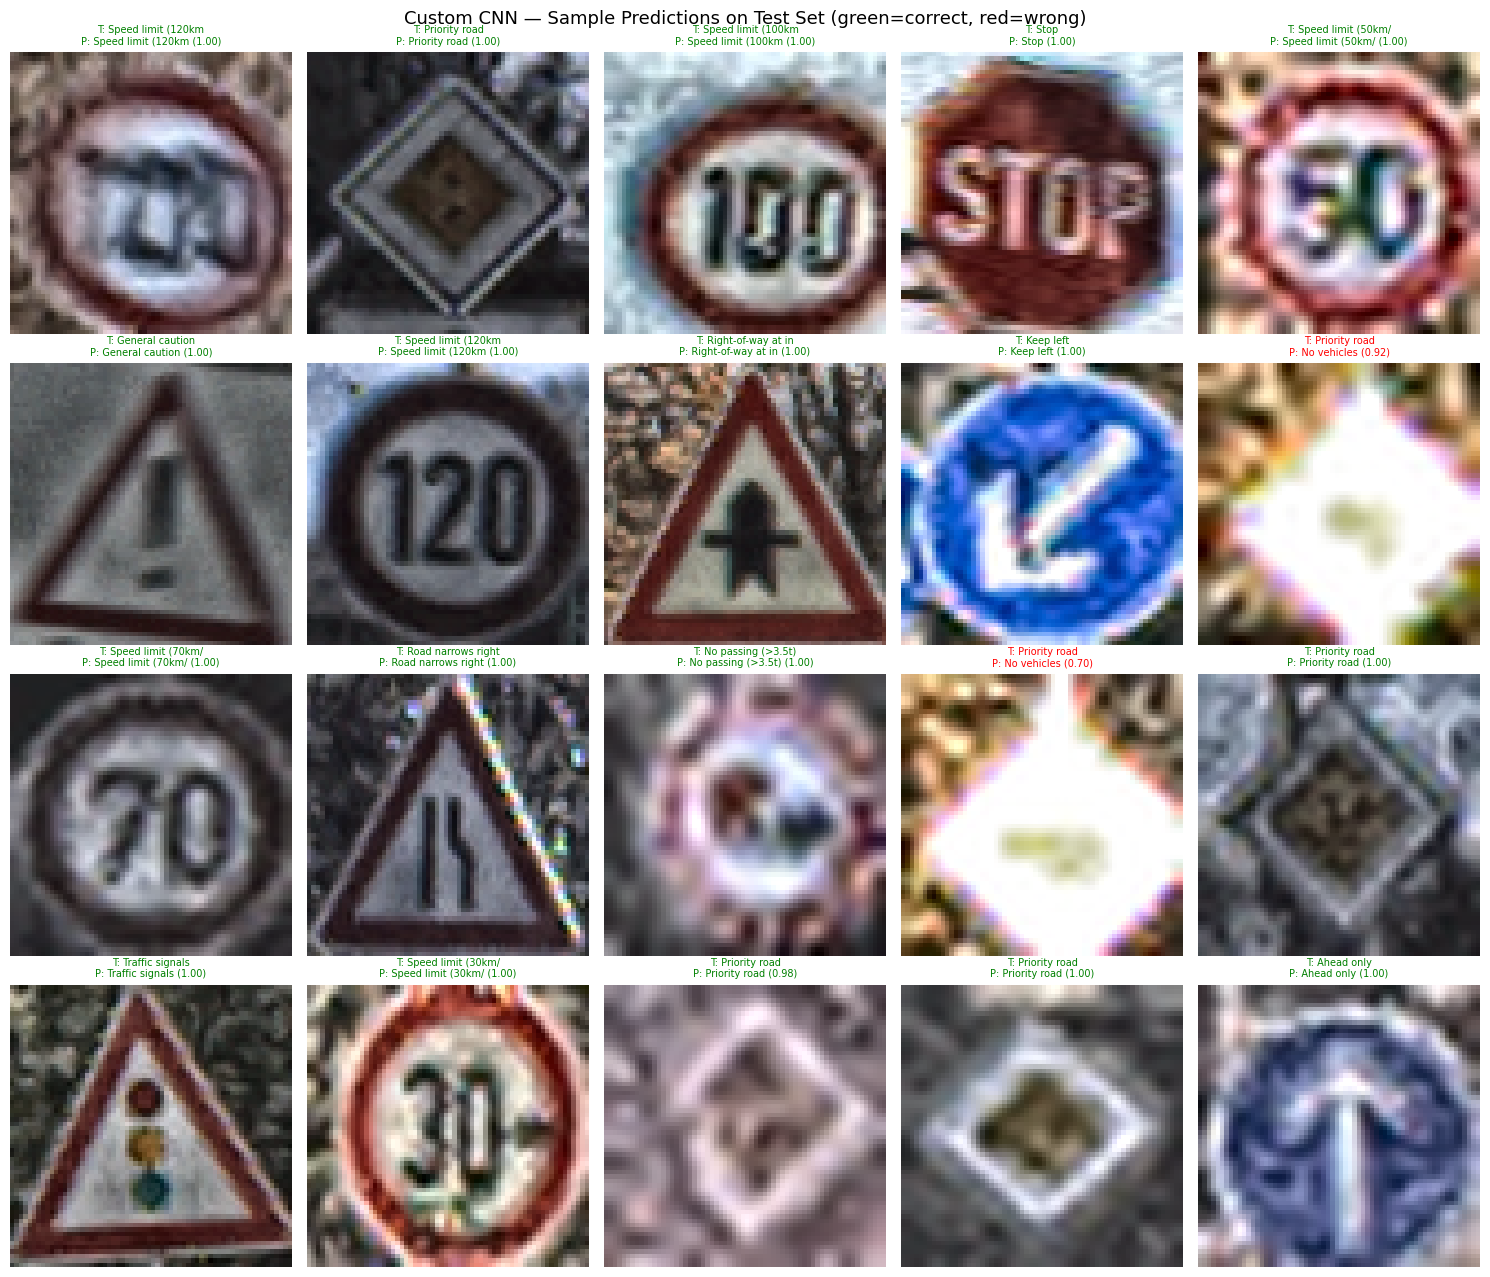

In [8]:
rng = np.random.default_rng(42)
indices = rng.integers(0, len(X_test), size=20)

fig, axes = plt.subplots(4, 5, figsize=(15, 13))
axes = axes.ravel()

best_proba = cnn_proba if acc_cnn >= acc_mobile else mobile_proba

for i, idx in enumerate(indices):
    axes[i].imshow(X_test[idx])
    true_lbl = y_test[idx]
    pred_lbl = np.argmax(best_proba[idx])
    conf     = best_proba[idx][pred_lbl]
    color    = 'green' if true_lbl == pred_lbl else 'red'
    axes[i].set_title(
        f'T: {CLASS_NAMES[true_lbl][:18]}\nP: {CLASS_NAMES[pred_lbl][:18]} ({conf:.2f})',
        fontsize=7, color=color
    )
    axes[i].axis('off')

plt.suptitle(f'{best_name} — Sample Predictions on Test Set (green=correct, red=wrong)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 8. Per-Class Accuracy (Top 10 worst)

10 hardest classes (Custom CNN, Test Set):
 class                        name  accuracy  count
    22                  Bumpy road  0.858333    120
    42   End of no passing (>3.5t)  0.888889     90
    12               Priority road  0.955072    690
     8       Speed limit (120km/h)  0.964444    450
    27                 Pedestrians  0.966667     60
    26             Traffic signals  0.966667    180
     6 End of speed limit (80km/h)  0.966667    150
     3        Speed limit (60km/h)  0.966667    450
    40        Roundabout mandatory  0.966667     90
    18             General caution  0.976923    390


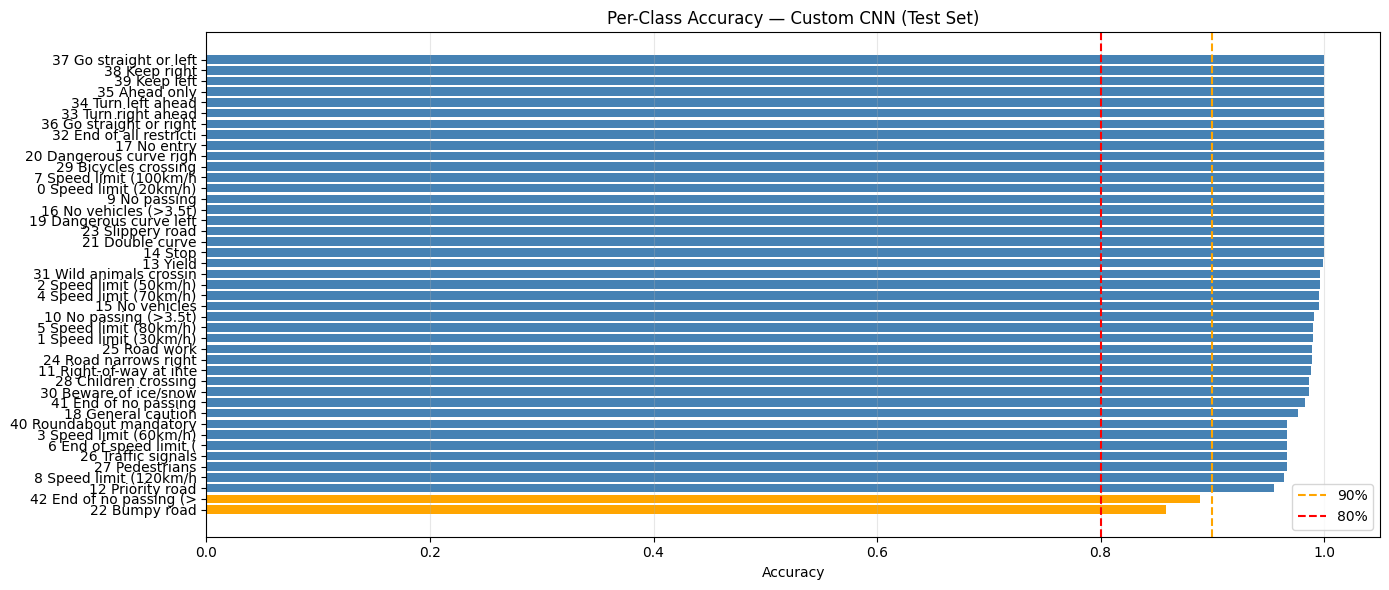

In [9]:
per_class_acc = []
for cls in range(NUM_CLASSES):
    mask = y_test == cls
    if mask.sum() > 0:
        acc = (y_pred_cnn[mask] == cls).mean()
        per_class_acc.append({'class': cls, 'name': CLASS_NAMES[cls], 'accuracy': acc, 'count': int(mask.sum())})

per_cls_df = pd.DataFrame(per_class_acc).sort_values('accuracy')
print("10 hardest classes (Custom CNN, Test Set):")
print(per_cls_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
colors_bar = ['red' if a < 0.8 else 'orange' if a < 0.9 else 'steelblue'
               for a in per_cls_df['accuracy']]
ax.barh(per_cls_df['class'].astype(str) + ' ' + per_cls_df['name'].str[:20],
         per_cls_df['accuracy'], color=colors_bar)
ax.axvline(0.9, color='orange', linestyle='--', label='90%')
ax.axvline(0.8, color='red',    linestyle='--', label='80%')
ax.set_xlabel('Accuracy')
ax.set_title('Per-Class Accuracy — Custom CNN (Test Set)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()